In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt

!pip install optuna
import optuna

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.8 MB/s eta 0:00:00


In [ ]:
def prepare_data(df):
    # Preprocessing
    # Fill missing event data
    df['Event_Name'] = df['Event_Name'].fillna('None')
    df['Event_Type'] = df['Event_Type'].fillna('None')

    # Convert Timestamp to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values(by=['Road_Segment_ID', 'Timestamp'])

    # Time Feature Extraction
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['Month'] = df['Timestamp'].dt.month
    df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

    # Cyclical Encoding for Time
    df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

    # Lag Features & Rolling Stats (Advanced Feature Engineering)
    # Group by Road_Segment_ID to ensure lags are relevant to the specific road
    df['prev_hour_traffic'] = df.groupby('Road_Segment_ID')['Vehicle_Count_Traffic_Demand'].shift(1)
    df['prev_2hour_traffic'] = df.groupby('Road_Segment_ID')['Vehicle_Count_Traffic_Demand'].shift(2)
    df['rolling_mean_3h'] = df.groupby('Road_Segment_ID')['Vehicle_Count_Traffic_Demand'].shift(1).rolling(window=3).mean()

    # Drop rows with NaN from lags
    df = df.dropna()

    # Encoding Categorical Features
    cat_cols = ['Road_Segment_ID', 'Weather_Condition', 'Road_Type', 'Traffic_Signals', 'Event_Type']
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

    # Save encoders for later use in Flask app
    os.makedirs('models', exist_ok=True)
    joblib.dump(label_encoders, 'models/label_encoders.pkl')

    return df

In [39]:
df = pd.read_csv('data/traffic_prediction_dataset.csv')
processed_df = prepare_data(df)
processed_df.to_csv('data/processed_traffic_data.csv', index=False)
print("Preprocessing and Feature Engineering completed. Processed data saved.")

Preprocessing and Feature Engineering completed. Processed data saved.


In [4]:
# Ensure outputs directory exists
os.makedirs('outputs', exist_ok=True)

In [ ]:
# Basic Info
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

In [ ]:
# Summary Statistics
summary = df.describe()
summary.to_csv('outputs/summary_statistics.csv')

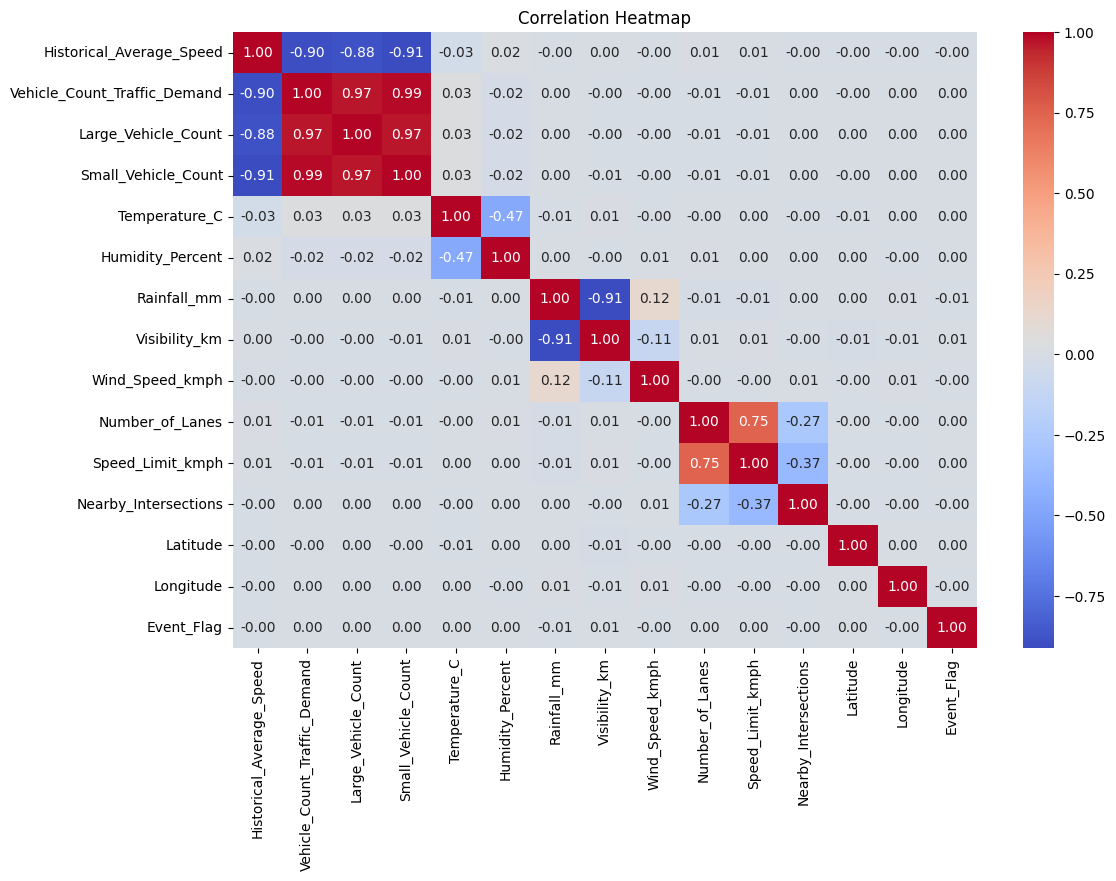

In [ ]:
# Correlation Heatmap (Numerical columns only)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('outputs/correlation_heatmap.png')
plt.show()
plt.close()

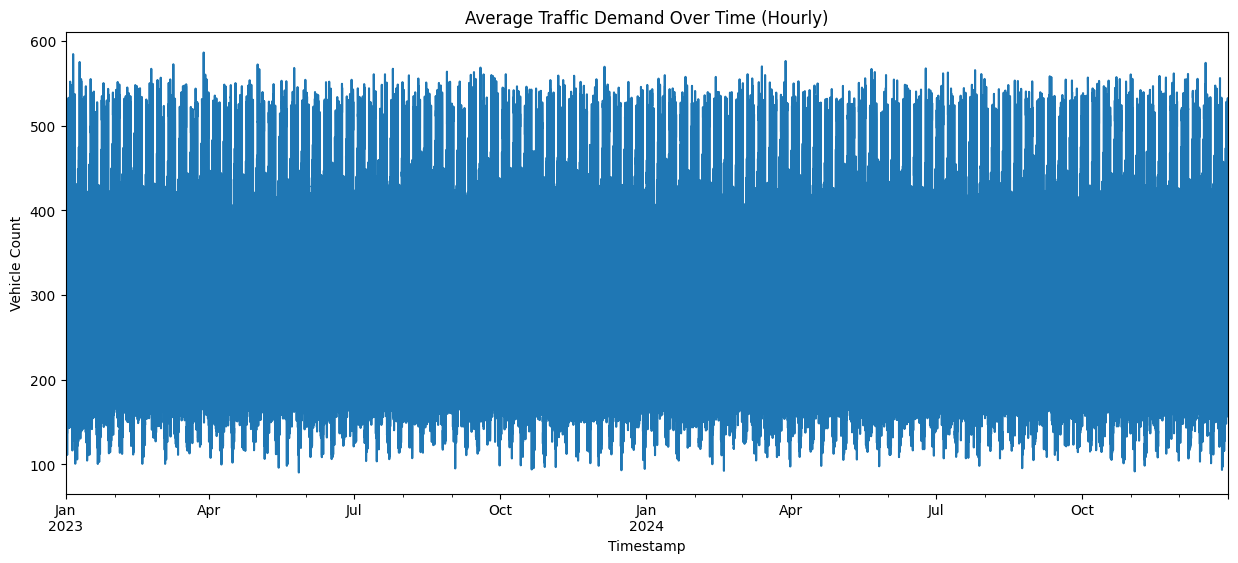

In [ ]:
# Traffic Trend Over Time
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_time = df.set_index('Timestamp')
df_time['Vehicle_Count_Traffic_Demand'].resample('h').mean().plot(figsize=(15, 6))
plt.title('Average Traffic Demand Over Time (Hourly)')
plt.ylabel('Vehicle Count')
plt.savefig('outputs/traffic_trend.png')
plt.show()
plt.close()

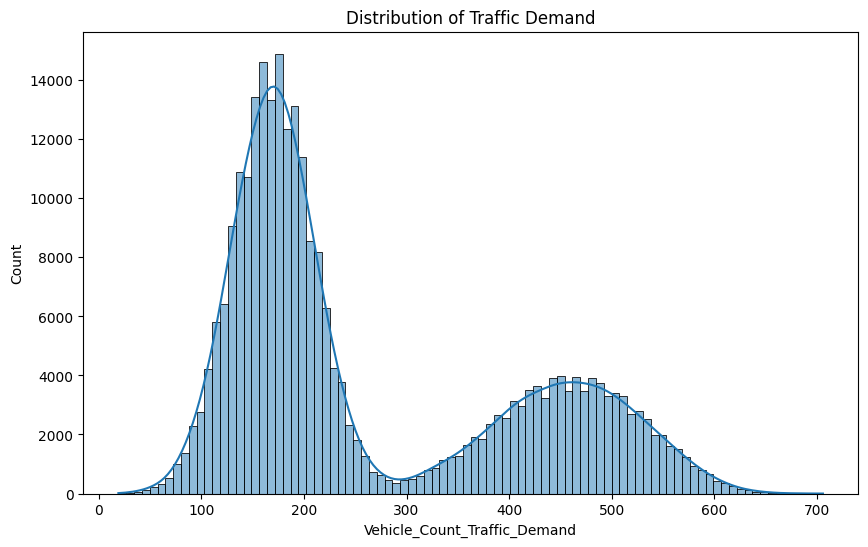

In [ ]:
# Distribution of Vehicle Count
plt.figure(figsize=(10, 6))
sns.histplot(df['Vehicle_Count_Traffic_Demand'], kde=True)
plt.title('Distribution of Traffic Demand')
plt.savefig('outputs/traffic_distribution.png')
plt.show()
plt.close()

In [11]:
# Evaluation helper functions
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.where(y_true == 0, 1e-10, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [29]:
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred))
    denominator = np.where(denominator == 0, 1e-10, denominator)
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / denominator)

In [12]:
# Select Features and Target
exclude_cols = ['Timestamp', 'Road_Coordinates', 'Event_Name', 'Vehicle_Count_Traffic_Demand',
                'Large_Vehicle_Count', 'Small_Vehicle_Count', 'Latitude', 'Longitude']
features = [col for col in df.columns if col not in exclude_cols]
target = 'Vehicle_Count_Traffic_Demand'

In [18]:
X = processed_df[features]
y = processed_df[target]

In [19]:
# Time-series aware split (80% train, 20% test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [20]:
print(f"Training on {len(X_train)} samples, Testing on {len(X_test)} samples")

Training on 224563 samples, Testing on 53741 samples


In [ ]:
# Hyperparameter Tuning with Optuna 
def objective_lgbm(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'verbosity': -1,
        'random_state': 42
    }
    model = LGBMRegressor(**param)
    # Using simple split for speed in demo, normally use TimeSeriesSplit
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

In [21]:
print("\nTuning LightGBM...")
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=5)
lgbm_best_params = study_lgbm.best_params

[I 2026-06-28 14:12:30,578] A new study created in memory with name: no-name-d06c7082-8f31-4873-bc03-b9bedb38d3e4



Tuning LightGBM...


[I 2026-06-28 14:12:34,402] Trial 0 finished with value: 0.8760729879472198 and parameters: {'n_estimators': 157, 'learning_rate': 0.0742813359652327, 'max_depth': 5, 'num_leaves': 137}. Best is trial 0 with value: 0.8760729879472198.
[I 2026-06-28 14:12:39,775] Trial 1 finished with value: 0.8672504586914747 and parameters: {'n_estimators': 212, 'learning_rate': 0.2828367337858532, 'max_depth': 5, 'num_leaves': 64}. Best is trial 0 with value: 0.8760729879472198.
[I 2026-06-28 14:12:45,363] Trial 2 finished with value: 0.8734598670612171 and parameters: {'n_estimators': 384, 'learning_rate': 0.2782550209208014, 'max_depth': 3, 'num_leaves': 64}. Best is trial 0 with value: 0.8760729879472198.
[I 2026-06-28 14:12:48,275] Trial 3 finished with value: 0.8751547400236886 and parameters: {'n_estimators': 106, 'learning_rate': 0.11226141770481915, 'max_depth': 5, 'num_leaves': 41}. Best is trial 0 with value: 0.8760729879472198.
[I 2026-06-28 14:12:57,336] Trial 4 finished with value: 0.866

In [22]:
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'random_state': 42
    }
    model = XGBRegressor(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return r2_score(y_test, preds)

In [23]:
print("Tuning XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=5)
xgb_best_params = study_xgb.best_params

[I 2026-06-28 14:13:09,009] A new study created in memory with name: no-name-253f7924-3407-41ff-b521-56e6c465a8f0


Tuning XGBoost...


[I 2026-06-28 14:13:21,620] Trial 0 finished with value: 0.8601736426353455 and parameters: {'n_estimators': 498, 'learning_rate': 0.1329395188090312, 'max_depth': 7}. Best is trial 0 with value: 0.8601736426353455.
[I 2026-06-28 14:13:37,443] Trial 1 finished with value: 0.8405624628067017 and parameters: {'n_estimators': 401, 'learning_rate': 0.22791736261438464, 'max_depth': 9}. Best is trial 0 with value: 0.8601736426353455.
[I 2026-06-28 14:13:44,162] Trial 2 finished with value: 0.8635518550872803 and parameters: {'n_estimators': 167, 'learning_rate': 0.17171119592552728, 'max_depth': 8}. Best is trial 2 with value: 0.8635518550872803.
[I 2026-06-28 14:13:52,050] Trial 3 finished with value: 0.8717458248138428 and parameters: {'n_estimators': 270, 'learning_rate': 0.04642436522041839, 'max_depth': 8}. Best is trial 3 with value: 0.8717458248138428.
[I 2026-06-28 14:13:59,732] Trial 4 finished with value: 0.8686447143554688 and parameters: {'n_estimators': 258, 'learning_rate': 0.

In [ ]:
# Final Models Training
print("\nTraining optimized models...")
lgbm_final = LGBMRegressor(**lgbm_best_params, verbosity=-1, random_state=42)
xgb_final = XGBRegressor(**xgb_best_params, random_state=42)


Training optimized models...


In [25]:
lgbm_final.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04642436522041839, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=270, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
# Blending Ensemble (LightGBM 55% + XGBoost 45%)
lgbm_preds = lgbm_final.predict(X_test)
xgb_preds = xgb_final.predict(X_test)
y_pred = (0.55 * lgbm_preds) + (0.45 * xgb_preds)

In [30]:
# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
smape = symmetric_mean_absolute_percentage_error(y_test, y_pred)

In [31]:
print(f"\nFinal Blending Ensemble Performance:")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")


Final Blending Ensemble Performance:
R2 Score: 0.8753
RMSE: 51.33
MAE: 38.19
MAPE: 17.81%
SMAPE: 16.57%


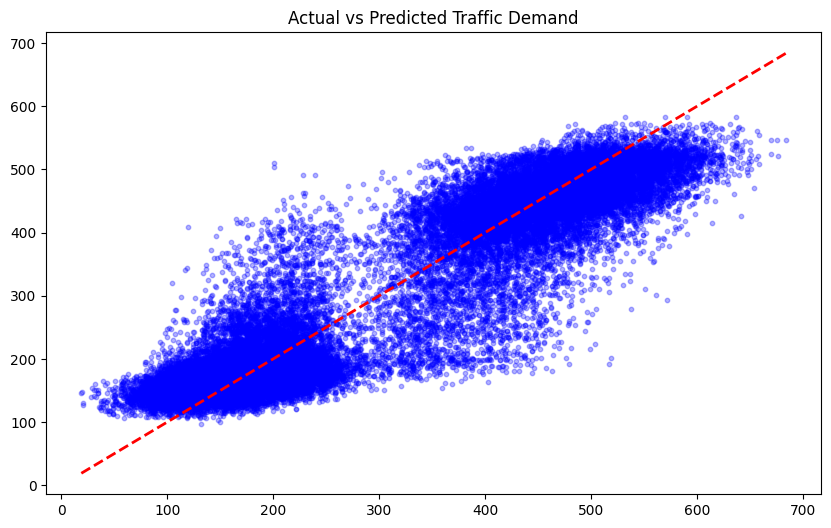

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Traffic Demand')
plt.savefig('outputs/actual_vs_predicted.png')
plt.show()
plt.close()

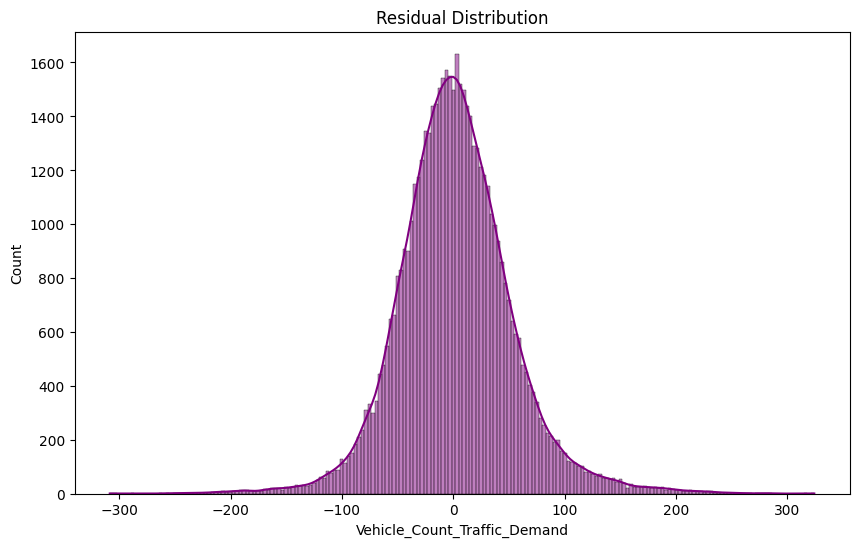

In [ ]:
# Residual Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True, color='purple')
plt.title('Residual Distribution')
plt.savefig('outputs/residual_distribution.png')
plt.show()
plt.close()

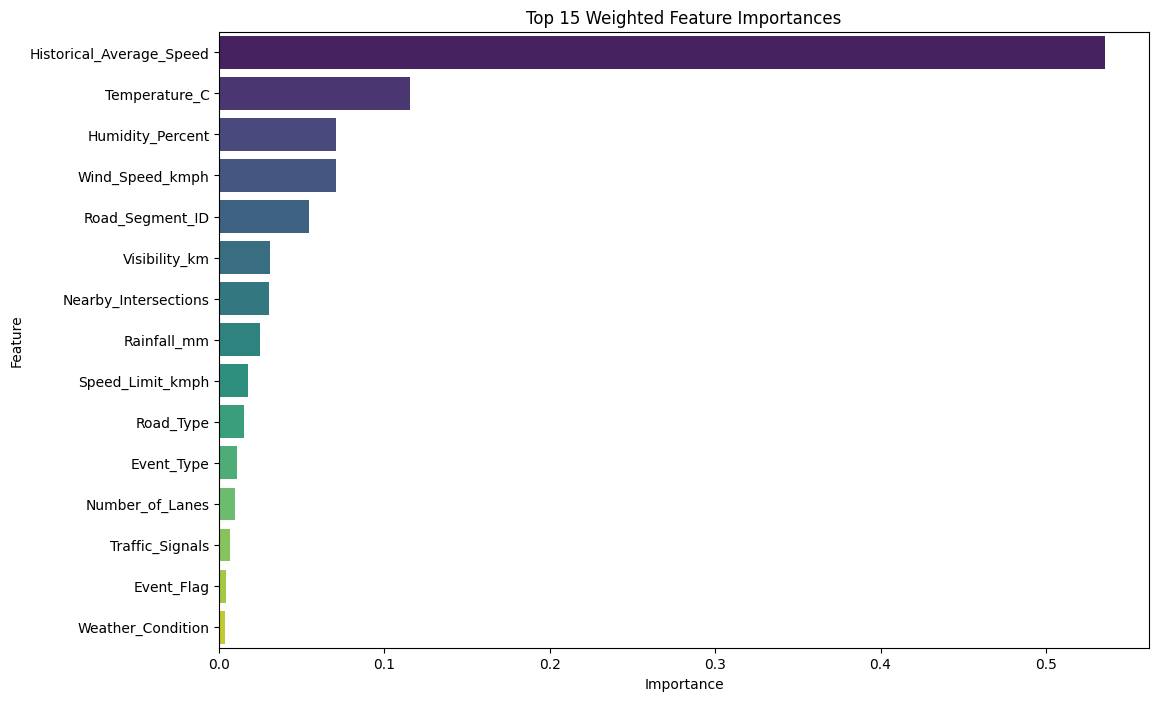

In [ ]:
# Feature Importance (Weighted)
importance = (0.55 * lgbm_final.feature_importances_ / lgbm_final.feature_importances_.sum()) + \
             (0.45 * xgb_final.feature_importances_ / xgb_final.feature_importances_.sum())
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', legend=False, palette='viridis')
plt.title('Top 15 Weighted Feature Importances')
plt.savefig('outputs/feature_importance.png')
plt.show()
plt.close()


In [36]:
class TrafficEnsemble:
    def __init__(self, lgbm, xgb):
        self.lgbm = lgbm
        self.xgb = xgb

    def predict(self, X):
        return (0.55 * self.lgbm.predict(X)) + (0.45 * self.xgb.predict(X))

In [37]:
# Save the best models and the ensemble
os.makedirs('models', exist_ok=True)
joblib.dump(lgbm_final, 'models/lgbm_model.pkl')
joblib.dump(xgb_final, 'models/xgb_model.pkl')

ensemble_model = TrafficEnsemble(lgbm_final, xgb_final)
joblib.dump(ensemble_model, 'models/ensemble_model.pkl')

print("Optimized LightGBM, XGBoost, and Ensemble models saved successfully!")

Optimized LightGBM, XGBoost, and Ensemble models saved successfully!
